# Drift sweep — one district at a time, at several strengths

Grid: **network** x **which district drifts** x **drift strength**. The initial map is
all residential, so in the final phase exactly one district differs from the rest and every
regime statistic has a real contrast to resolve.

Three questions it is built to answer.

**(a) Which gauges carry the signal, per network.** Two different answers, both needed:
gauges that *resemble* their district (a property of the network and the placement, scored
in the drift-free phase and averaged over the whole grid) and gauges that *respond* when
their own district is the one drifting (scored only in the cells where that happens).

**(b) Does the shape model carry the drift, or is detection reading a level change.** The
beta ladder. `beta = 0` is volume-neutral — the signature changes and the volume does not.
If detection needs `beta >= 0.6`, the detector is reading level and the consumption
attribution needs work rather than the sensors.

**(c) How much of the response is contamination.** The leak matrix: drift district on the
rows, where the response was measured on the columns. Off-diagonal is hydraulic coupling
arriving through shared pipes.

Engines: `landuse_sweep.py` on top of `landuse_world.py` + `signal_probe.py`. The drift
engine and the FL stack are still untouched.

## 0. Setup

In [1]:
%matplotlib inline
import sys, warnings, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220, "display.max_columns", 80, "display.max_rows", 200)

HERE = pathlib.Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
for p in (HERE, ROOT / "src", ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import landuse_world as lw
import signal_probe as sp
import landuse_sweep as ls

OUT = ROOT / "data" / "09_experiments" / "landuse_sweep"
OUT.mkdir(parents=True, exist_ok=True)
print(ROOT)

c:\Users\arthu\USPy\10_Mestrado\fedWater


## 1. The grid

**Strength axis is `beta`, not income.** `level_factor = (intensity_ratio) ** beta`, and for
residential → industrial at low income the ratio is 9.19:

| beta | 0.00 | 0.15 | 0.35 | 0.60 | 1.00 |
|---|---|---|---|---|---|
| level | 1.00 | 1.39 | 2.17 | 3.78 | 9.19 |

`to_income` cannot do this. Income enters only through the residential plot intensity and
an industrial block is 20% residential by plot share, so the same ratio is 9.19 at low
income, 9.37 at medium and 9.70 at high — a 5% move against beta's 9x. Income would be the
right knob for a residential→residential level drift; that is a different experiment.

beta is global, but with an all-residential initial map every non-drifting district sits at
ratio 1.0 and therefore level_factor 1.0 for any beta. In this design beta moves the
drifting district alone. That stops being true the moment a second non-residential district
is in the initial map.

**Horizon is cut for cost.** 16 months of 14-day months is 5 376 steps against the POC's
33 600. `max_neighbors_per_month` is raised to 8 so the diffusion front finishes early
enough to leave a clean final phase inside that horizon — a change to the front's *width*,
not to the drift mechanism.

In [ ]:
CFG = ls.SweepCfg(
    networks=("ky7", "dtown"),
    betas=(0.0, 0.15, 0.25, 0.35, 0.40, 0.50),
    districts=None,                    # None = every district of every network
    to_land_use="industrial", to_income="low",
    n_months=44, days_per_month=14, warmup_months=2,
    max_neighbors_per_month=8, growth_chance=1.0,
    drift_ramp_days=7, seasonality_scale=0.0)

grid = ls.cells(CFG, ROOT)
print(f"{len(grid)} cells:",
      pd.Series([g.network for g in grid]).value_counts().to_dict())
print("KY7 districts  :", ls.district_names(ROOT, "ky7"))
print("D-Town districts:", ls.district_names(ROOT, "dtown"))
print("\nrough cost: KY7 ~30 s/cell, D-Town ~150 s/cell at this horizon.")

30 cells: {'graeme': 30}
KY7 districts  : ['District_A', 'District_B', 'District_C', 'District_D']
D-Town districts: ['District_A', 'District_B', 'District_C', 'District_D', 'District_E']
Graeme districts: ['District_A', 'District_B', 'District_C', 'District_D', 'District_E']

rough cost: KY7 ~30 s/cell, D-Town ~150 s/cell at this horizon.


## 2. Run

Cells are content-addressed by `sim_hash` and cached, so an interrupted sweep resumes and a
widened grid only pays for the new cells. A cell that fails — usually V3, the pressure
floor, at high beta — is recorded with its error and the sweep continues: an infeasible
corner is a result about the network's capacity, not a reason to lose the grid.

In [5]:
CELLS, SCORES, DELTAS = ls.run_sweep(CFG, ROOT, OUT, cache=True, phase="final")

run_hydraulics: 1 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['110']).
  [1/30] graeme/District_A/beta=0.0  solved dDemand    +0.4%  shift 0.72  flow gap 1.76  resp 1.00  16s  | eta 8 min
run_hydraulics: 1 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['110']).
  [2/30] graeme/District_A/beta=0.15  solved dDemand   +40.0%  shift 0.72  flow gap 1.82  resp 1.00  14s  | eta 7 min
run_hydraulics: 1 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['110']).
  [3/30] graeme/District_A/beta=0.25  solved dDemand   +74.8%  shift 0.72  flow gap 1.86  resp 1.00  13s  | eta 6 min
run_hydraulics: 1 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['110']).
  [4/30] graeme/District_A/beta=0.35  solved dDemand  +118.2%  shift 0.72  flow gap 1.88  resp 1.00  12s  | eta 6 min
run_hydraulics: 1 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['110']).
  [5/30] graeme/District_A/beta=0.4  solved dDema

In [6]:
print(CELLS.groupby(["network", "status"]).size().to_string())
display(CELLS[CELLS["status"] != "ok"][["network", "drift_district", "beta", "error"]])
CELLS[CELLS["status"] == "ok"].groupby("network")[
    ["d_demand_%", "shape_shift", "d_pressure", "seconds"]].describe().round(2).T

network  status
graeme   ok        30


,network,drift_district,beta,error


network            graeme
d_demand_%  count   30.00
            mean    96.38
            std     68.33
            min     -0.02
            25%     39.62
            50%     96.04
            75%    142.96
            max    204.32
shape_shift count   30.00
            mean     0.72
            std      0.00
            min      0.72
            25%      0.72
            50%      0.72
            75%      0.72
            max      0.73
d_pressure  count   30.00
            mean    -1.18
            std      1.55
            min     -5.58
            25%     -2.01
            50%     -0.67
            75%     -0.16
            max      0.63
seconds     count   30.00
            mean    14.21
            std      1.40
            min     12.40
            25%     13.22
            50%     13.95
            75%     15.15
            max     18.00

Where the sweep fails is informative on its own. D-Town's anchor sits at 0.25 against a
cliff measured between 0.35 and 0.50, so a district converting to industrial at `beta = 1.0`
(9.2x its own level) is a real capacity question, not a bug. If whole districts fail at
high beta, that is the network saying the drift magnitude the detector wants is outside its
hydraulic envelope — which would itself be an argument for making the *shape* carry the
signal instead of the level.

## 3. The beta ladder — does shape alone carry the drift?

`resp_flow_top` is the mean response of the drifting district's three best-resembling flow
gauges: the correlation between how the gauge's weekly signature moved and how the
district's demand signature moved. It is computed on z-scored profiles, so a pure level
change scores 0 — the number only moves if the *shape* moved.

Read the ladder bottom-up. High response already at `beta = 0` means the sector signature
alone is legible and the attribution protocol is fine. Response that only appears at
`beta >= 0.6` means the detector is reading volume.

,network,drift_district,beta,d_demand_%,shape_shift,d_pressure,gap_flow,gap_pressure,resp_flow_top,resp_pressure_top,resp_leak_p95,status
0,graeme,District_A,0.00,0.404,0.725,0.102,1.760,0.698,1.000,0.561,0.955,ok
1,graeme,District_A,0.15,40.031,0.725,-0.031,1.824,0.716,1.000,0.597,0.955,ok
2,graeme,District_A,0.25,74.799,0.725,-0.151,1.856,0.732,1.000,0.616,0.955,ok
3,graeme,District_A,0.35,118.200,0.725,-0.305,1.883,0.749,1.000,0.632,0.955,ok
4,graeme,District_A,0.40,143.788,0.725,-0.398,1.894,0.759,1.000,0.639,0.955,ok
5,graeme,District_A,0.50,204.318,0.725,-0.623,1.914,0.782,1.000,0.654,0.955,ok
6,graeme,District_B,0.00,0.086,0.729,0.628,1.827,0.583,0.998,0.730,0.943,ok
7,graeme,District_B,0.15,39.587,0.729,-0.338,1.804,0.627,0.999,0.765,0.929,ok
8,graeme,District_B,0.25,74.245,0.729,-1.283,1.777,0.659,1.000,0.791,0.923,ok
9,graeme,District_B,0.35,117.508,0.729,-2.587,1.703,0.696,1.000,0.818,0.923,ok


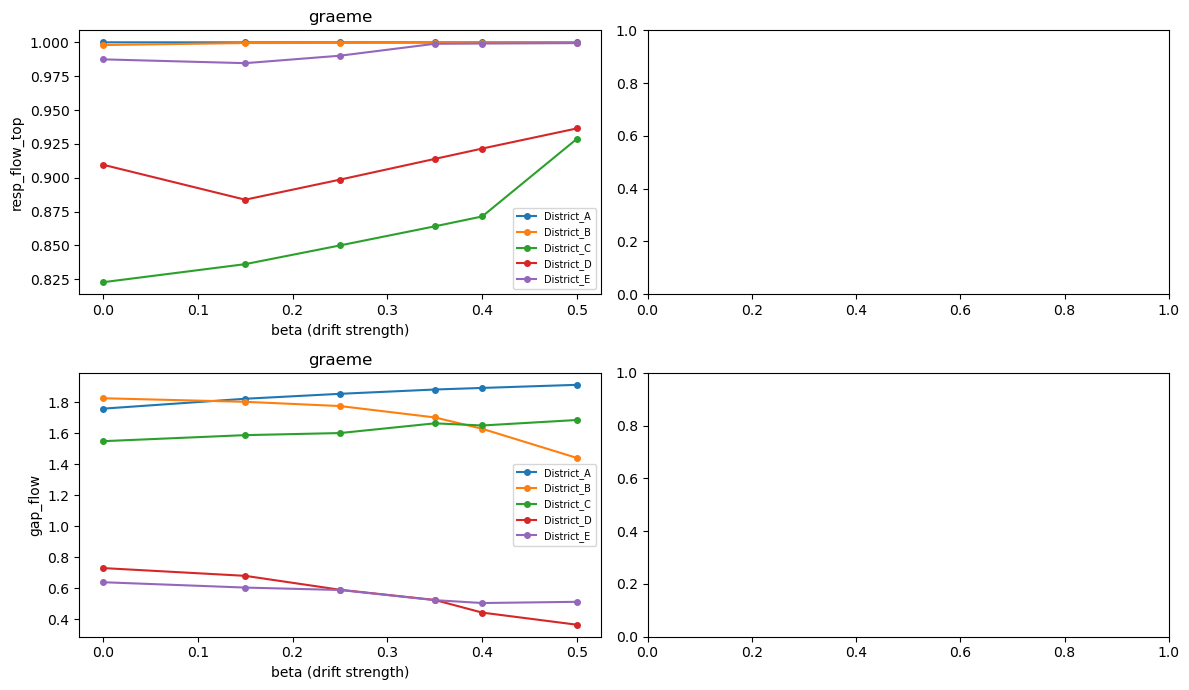

In [7]:
L = ls.beta_ladder(CELLS)
display(L.round(3))
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
ls.plot_beta_ladder(CELLS, "resp_flow_top", axes=axes[0])
ls.plot_beta_ladder(CELLS, "gap_flow", axes=axes[1])
plt.tight_layout(); plt.show()

In [8]:
display(ls.beta_threshold(CELLS, "resp_flow_top", 0.5))
display(ls.beta_threshold(CELLS, "resp_pressure_top", 0.3))

,network,drift_district,cells_ok,min_beta[resp_flow_top>=0.5]
0,graeme,District_A,6,0.0
1,graeme,District_B,6,0.0
2,graeme,District_C,6,0.0
3,graeme,District_D,6,0.0
4,graeme,District_E,6,0.0


,network,drift_district,cells_ok,min_beta[resp_pressure_top>=0.3]
0,graeme,District_A,6,0.0
1,graeme,District_B,6,0.0
2,graeme,District_C,6,0.0
3,graeme,District_D,6,0.0
4,graeme,District_E,6,0.0


Two controls worth checking against the ladder before reading it as a result.

`shape_shift` at `beta = 0` should already be large — it is the drift-induced change in the
district's own demand profile, before any hydraulics. If it is small, the sector signatures
are too close and the problem is upstream of the sensors.

`d_demand_%` at `beta = 0` should be ~0. If it is not, beta is not doing what the level
model says and the ladder is confounded.

,network,drift_district,d_demand_%,shape_shift,resp_flow_top,resp_pressure_top,gap_flow
0,graeme,District_A,0.404,0.725,1.000,0.561,1.760
6,graeme,District_B,0.086,0.729,0.998,0.730,1.827
12,graeme,District_C,-0.017,0.723,0.823,0.617,1.550
18,graeme,District_D,0.000,0.720,0.910,0.675,0.731
24,graeme,District_E,0.174,0.725,0.987,0.700,0.639


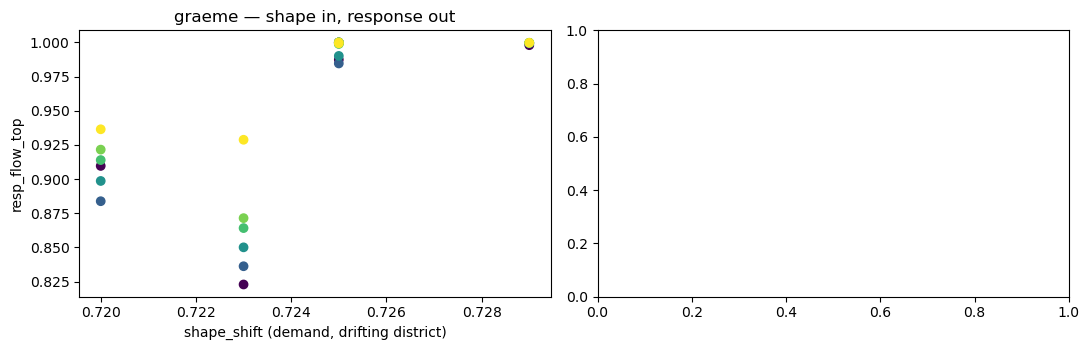

In [9]:
base = CELLS[(CELLS["beta"] == 0.0) & (CELLS["status"] == "ok")]
display(base[["network", "drift_district", "d_demand_%", "shape_shift",
              "resp_flow_top", "resp_pressure_top", "gap_flow"]].round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, net in zip(ax, sorted(CELLS["network"].unique())):
    d = CELLS[(CELLS["network"] == net) & (CELLS["status"] == "ok")]
    a.scatter(d["shape_shift"], d["resp_flow_top"], c=d["beta"], cmap="viridis", s=36)
    a.set(xlabel="shape_shift (demand, drifting district)",
          ylabel="resp_flow_top", title=f"{net} — shape in, response out")
plt.tight_layout(); plt.show()

## 4. The leak — how much response lands outside the drifting district

Rows: which district drifted. Columns: where the response was measured, using each
district's three best-resembling flow gauges. The diagonal is signal, everything off it is
hydraulic contamination.

On a closed network the off-diagonal cannot be zero. The ratio of diagonal to off-diagonal
is the de-confounding problem stated in numbers, per network — and the expectation from the
Graeme work is that D-Town's decoupled districts give a much cleaner diagonal than KY7,
where everything floats on three shared tanks.

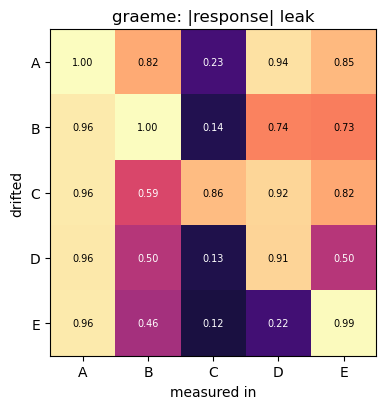

graeme: diagonal 0.953 | off-diagonal 0.626 | ratio 1.5x


In [10]:
M = ls.leak_matrix(SCORES, phase="final", kind="flow", top=3)
fig, axes = plt.subplots(1, len(M), figsize=(5.0 * len(M), 4.2))
ls.plot_leak(M, axes=np.atleast_1d(axes))
plt.tight_layout(); plt.show()

for net, A in M.items():
    diag = np.diag(A.to_numpy())
    off = A.to_numpy()[~np.eye(len(A), dtype=bool)]
    print(f"{net}: diagonal {diag.mean():.3f} | off-diagonal {off.mean():.3f} "
          f"| ratio {diag.mean() / max(off.mean(), 1e-9):.1f}x")

In [11]:
# Same thing on pressure. If the pressure leak ratio is near 1, a pressure gauge cannot
# tell its own district's drift from a neighbour's — which is the specific failure mode
# that makes pressure useless for attribution, distinct from it being noisy.
Mp = ls.leak_matrix(SCORES, phase="final", kind="pressure", top=3)
for net, A in Mp.items():
    diag = np.diag(A.to_numpy())
    off = A.to_numpy()[~np.eye(len(A), dtype=bool)]
    print(f"{net} pressure: diag {diag.mean():.3f} | off {off.mean():.3f} "
          f"| ratio {diag.mean() / max(off.mean(), 1e-9):.1f}x")
display(Mp["dtown"].round(3) if "dtown" in Mp else Mp)

graeme pressure: diag 0.714 | off 0.073 | ratio 9.8x


{'graeme':             District_A  District_B  District_C  District_D  District_E
 District_A    0.616532    0.116010    0.054587    0.114509    0.074334
 District_B    0.012883    0.799141    0.080873    0.099726    0.064336
 District_C    0.060706    0.120836    0.659959    0.042464    0.026930
 District_D    0.013350    0.135697    0.068617    0.730422    0.052590
 District_E    0.010675    0.136570    0.073201    0.099425    0.762620}

## 5. (a) Which gauges carry the signal

**Resemblance carriers** are scored in the drift-free `init` phase and averaged across every
cell in the grid, so they are a property of the network and the placement rather than of any
one drift. `r_std` is the stability, and `share` in the next table is how often the gauge
landed in its district's top 5 across all cells — near 1.0 means placement can be decided
once and reused.

,network,district,kind,id,role,r_mean,r_std,r_min,count,rank
0,graeme,District_A,flow,q_103,internal,1.000,0.0,1.000,30,1.0
1,graeme,District_A,flow,q_102,internal,0.964,0.0,0.964,30,2.0
2,graeme,District_A,flow,q_175,internal,0.953,0.0,0.953,30,3.0
3,graeme,District_A,flow,q_176,internal,0.940,0.0,0.940,30,4.0
4,graeme,District_A,flow,q_173,internal,0.917,0.0,0.917,30,5.0
10,graeme,District_B,flow,q_131,internal,0.987,0.0,0.987,30,1.0
11,graeme,District_B,flow,q_136,boundary,0.951,0.0,0.951,30,2.0
12,graeme,District_B,flow,q_156,internal,0.943,0.0,0.943,30,3.0
13,graeme,District_B,flow,q_134,internal,0.943,0.0,0.943,30,4.0
14,graeme,District_B,flow,q_130,internal,0.938,0.0,0.938,30,5.0


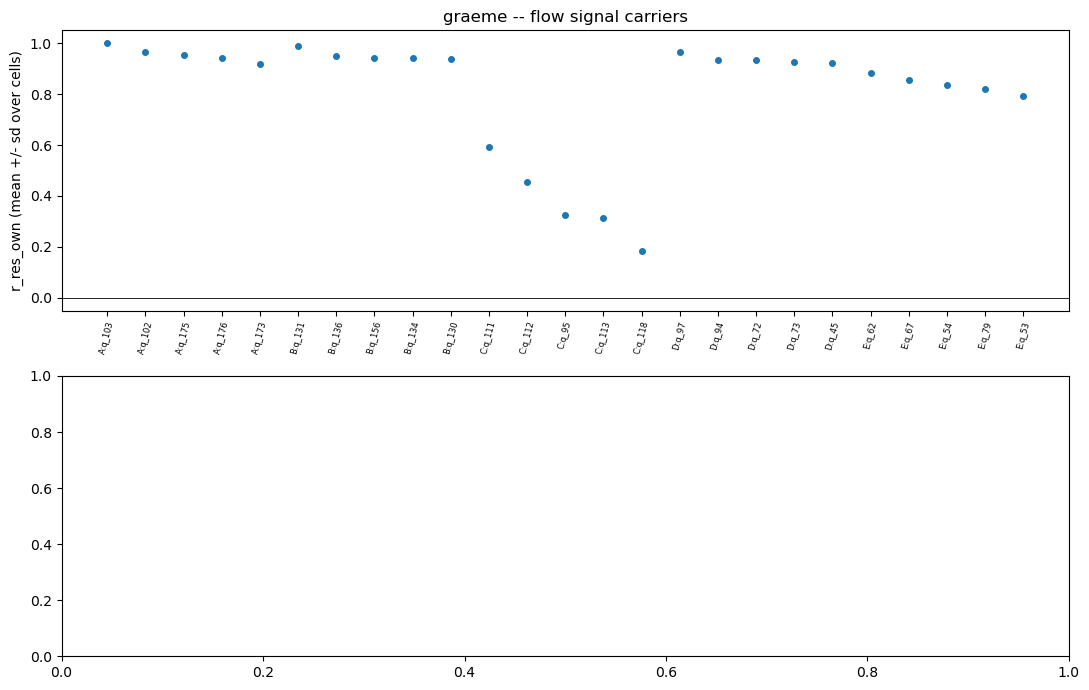

gauges with share >= 0.8
network kind                              
graeme  flow                            25
        pressure                        25

In [12]:
CAR = ls.signal_carriers(SCORES, phase="init", top=5)
STAB = ls.stability(SCORES, phase="init", top=5)
display(CAR[CAR["kind"] == "flow"].round(3))

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
for ax, net in zip(axes, sorted(SCORES["network"].unique())):
    ls.plot_carriers(CAR, net, "flow", ax=ax)
plt.tight_layout(); plt.show()

display(STAB[STAB["share"] >= 0.8].groupby(["network", "kind"]).size()
        .rename("gauges with share >= 0.8").to_frame())

**Response carriers** are the stricter test: restricted to the cells where this gauge's own
district is the drifting one, ranked by response rather than resemblance. `beta_min` is the
smallest strength at which that gauge already responded above 0.5 — the per-gauge version of
the ladder.

In [13]:
DRF = ls.drift_carriers(SCORES, phase="final", top=5)
display(DRF[DRF["kind"] == "flow"].round(3))
display(DRF[DRF["kind"] == "pressure"].round(3))

,network,district,kind,id,role,resp_mean,resp_std,r_mean,n,beta_min,rank
0,graeme,District_A,flow,q_103,internal,1.000,0.000,1.000,6,0.0,1.0
1,graeme,District_A,flow,q_102,internal,1.000,0.000,1.000,6,0.0,2.0
2,graeme,District_A,flow,q_173,internal,1.000,0.000,1.000,6,0.0,3.0
3,graeme,District_A,flow,q_176,internal,1.000,0.000,1.000,6,0.0,4.0
4,graeme,District_A,flow,q_174,internal,1.000,0.000,1.000,6,0.0,5.0
10,graeme,District_B,flow,q_150,internal,1.000,0.000,1.000,6,0.0,1.0
11,graeme,District_B,flow,q_147,internal,1.000,0.000,1.000,6,0.0,2.0
12,graeme,District_B,flow,q_164,internal,0.999,0.000,1.000,6,0.0,3.0
13,graeme,District_B,flow,q_168,internal,0.999,0.001,1.000,6,0.0,4.0
14,graeme,District_B,flow,q_142,internal,0.999,0.000,1.000,6,0.0,5.0


,network,district,kind,id,role,resp_mean,resp_std,r_mean,n,beta_min,rank
5,graeme,District_A,pressure,p_61,internal,0.617,0.033,-0.433,6,0.0,1.0
6,graeme,District_A,pressure,p_53,internal,0.616,0.033,-0.433,6,0.0,2.0
7,graeme,District_A,pressure,p_62,internal,0.616,0.033,-0.433,6,0.0,3.0
8,graeme,District_A,pressure,p_106,internal,0.616,0.033,-0.433,6,0.0,4.0
9,graeme,District_A,pressure,p_75,internal,0.616,0.033,-0.433,6,0.0,5.0
15,graeme,District_B,pressure,p_88,internal,0.799,0.047,-0.228,6,0.0,1.0
16,graeme,District_B,pressure,p_84,internal,0.799,0.047,-0.228,6,0.0,2.0
17,graeme,District_B,pressure,p_83,internal,0.799,0.047,-0.228,6,0.0,3.0
18,graeme,District_B,pressure,p_92,internal,0.799,0.047,-0.228,6,0.0,4.0
19,graeme,District_B,pressure,p_90,internal,0.799,0.047,-0.228,6,0.0,5.0


In [14]:
# Do the two rankings agree? A gauge that resembles but does not respond is dominated by
# transit flow: the district's water passes through it, so it looks like the district and
# does not move when the district's behaviour changes.
J = (CAR.merge(DRF[["network", "district", "kind", "id", "resp_mean", "beta_min"]],
               on=["network", "district", "kind", "id"], how="outer", indicator=True))
print(J["_merge"].value_counts().to_string())
display(J[J["_merge"] == "both"][["network", "district", "kind", "id", "r_mean",
                                  "resp_mean", "beta_min"]].round(3))

_merge
left_only     26
right_only    26
both          24


,network,district,kind,id,r_mean,resp_mean,beta_min
0,graeme,District_A,flow,q_102,0.964,1.000,0.0
1,graeme,District_A,flow,q_103,1.000,1.000,0.0
2,graeme,District_A,flow,q_173,0.917,1.000,0.0
5,graeme,District_A,flow,q_176,0.940,1.000,0.0
6,graeme,District_A,pressure,p_106,0.010,0.616,0.0
7,graeme,District_A,pressure,p_53,0.010,0.616,0.0
8,graeme,District_A,pressure,p_61,0.010,0.617,0.0
9,graeme,District_A,pressure,p_62,0.010,0.616,0.0
10,graeme,District_A,pressure,p_75,0.010,0.616,0.0
22,graeme,District_B,pressure,p_83,-0.056,0.799,0.0


## 6. A placement chosen on the whole grid

Ranked by mean resemblance across every cell and tie-broken by stability, so the result is
the placement that holds whatever drifts next — rather than the one that happened to win in
a single world.

In [15]:
for net in sorted(SCORES["network"].unique()):
    prop = ls.proposed_sensors(SCORES, net, n_pressure=2, n_flow=3, phase="init")
    print(f"# ---- {net} ----")
    print(sp.sensors_yaml(prop), "\n")

# ---- graeme ----
sensors:
  District_A: {pressure: ["61", "53"], flow: ["103", "102", "175"]}
  District_B: {pressure: ["82", "83"], flow: ["131", "136", "156"]}
  District_C: {pressure: ["71", "72"], flow: ["111", "112", "95"]}
  District_D: {pressure: ["89", "25"], flow: ["97", "94", "72"]}
  District_E: {pressure: ["7", "10"], flow: ["62", "67", "54"]} 



In [16]:
# The shipped placement, scored on the same grid. `pct` is where each shipped gauge sits in
# its own (district, kind) ranking, averaged over cells.
d = SCORES[SCORES["phase"] == "init"].copy()
d["pct"] = d.groupby(["network", "sim_hash", "district", "kind"])["r_res_own"].rank(pct=True)
ship = (d[d["shipped"]].groupby(["network", "district", "kind", "id"])
        [["r_res_own", "pct", "response"]].mean().reset_index().round(3))
display(ship.sort_values(["network", "district", "kind"]))
print(ship.groupby(["network", "kind"])["pct"].mean().round(3).to_string())

,network,district,kind,id,r_res_own,pct,response
0,graeme,District_A,flow,q_100,0.603,0.529,0.473
1,graeme,District_A,flow,q_102,0.964,0.941,0.973
2,graeme,District_A,flow,q_85,0.358,0.353,0.487
3,graeme,District_A,pressure,p_64,0.010,0.091,0.136
4,graeme,District_A,pressure,p_75,0.010,0.818,0.136
5,graeme,District_B,flow,q_135,0.577,0.455,0.243
6,graeme,District_B,flow,q_157,0.157,0.250,0.423
7,graeme,District_B,flow,q_165,0.837,0.773,0.759
8,graeme,District_B,pressure,p_79,-0.058,0.138,0.256
9,graeme,District_B,pressure,p_86,-0.056,0.828,0.262


network  kind    
graeme   flow        0.419
         pressure    0.444


## 7. Read-out

**(a) Sensors.** §5 gives the two lists per network. Commit to a gauge only if it appears in
both — high `r_mean` with high `share` in the resemblance table, and high `resp_mean` with a
low `beta_min` in the response table. §6 turns that into a `sensors:` block; §6's second
cell says how much the shipped rule was leaving on the table.

**(b) Does the drift engine need work.** The decision is `beta_threshold` in §3. If
`min_beta[resp_flow_top>=0.5]` is 0.0 for most districts on both networks, the sector shape
signature carries the drift on its own and the consumption-attribution protocol is fine —
the remaining problem is placement and coupling, not the demand model. If it is 0.6 or 1.0,
or NaN, then detection depends on a level change of 4x–9x that D-Town's hydraulic envelope
may not even permit, and the protocol needs a stronger *shape* contrast: wider sector
separation, a night-floor or weekend gate that survives mixing, or a land-use mix that is
less residential-dominated by volume.

**Which districts are hopeless, and why.** A district with a flat ladder at every beta is
either badly metered (fix in §6) or hydraulically buried. Cross-check its row in the §4 leak
matrix against its `served_own` and its position in the supply chain: if its own gauges
respond no more than its neighbours' do, no placement fixes it and the district is a
candidate for exclusion rather than for a better sensor.

**Pressure.** If the pressure leak ratio in §4 is near 1 on both networks, pressure cannot
attribute a drift to a district even when it detects one, and pressure channels should be
dropped from the FL feature set rather than carried as noise.

### Next
Fix the placement from §6 into each bundle's `profile.yml`, regenerate the worlds, and only
then run FL. Training on the shipped placement would confound "the method cannot recover
regimes" with "the gauges never saw them".